In [1]:
import sys
sys.path.append("../") 

In [ ]:
!pip install pmdarima

   ---------------------------------------- 0.0/625.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.1 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.1 kB ? eta -:--:--
   ---------------------------------------- 625.1/625.1 kB 2.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 2.8 MB/s eta 0:00:01
   ----------------------- ---------------- 1.6/2.7 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 4.6 MB/s  0:00:00

   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   -------------------- ------------------- 1/2 [pmdarima]
   ---------

In [2]:
import pandas as pd

# Load Data
df = pd.read_csv("../../data/processed/Final_Wind_Data_Model.csv")

# Convert 'Date' column to datetime with correct format (DD-MM-YYYY)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Set 'Date' as datetime index
df = df.set_index("Date")

# Enforce monthly frequency
df = df.asfreq("MS")

# structure 
print(" Final shape (before dropna):", df.shape)
print(" Date range:", df.index.min().date(), "→", df.index.max().date())
print(" First few rows:\n", df.head())

# Drop only the rows with NaNs introduced by lag/rolling
df_clean = df.dropna()

print(" Final shape (after dropna):", df_clean.shape)


 Final shape (before dropna): (168, 9)
 Date range: 2011-01-01 → 2024-12-01
 First few rows:
             Wind_GWh  Wind_GWh_Lag1  Wind_GWh_Lag2  Wind_GWh_Lag12  \
Date                                                                 
2011-01-01   274.802        218.840        341.232         248.002   
2011-02-01   354.989        274.802        218.840         150.952   
2011-03-01   205.538        354.989        274.802         251.394   
2011-04-01   245.734        205.538        354.989         186.269   
2011-05-01   542.454        245.734        205.538         168.528   

            Wind_GWh_RollingMean3  Wind_Speed_10m  Temperature_Celsius  \
Date                                                                     
2011-01-01             278.291333        1.580421             5.126502   
2011-02-01             282.877000        4.150639             7.495865   
2011-03-01             278.443000        1.315118             7.115686   
2011-04-01             268.753667        1.82

Step 2: Stationarity Checks using ADF and KPSS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

# Select Target Variable
y = df_clean["Wind_GWh"]

# Plot Time Series 
plt.figure(figsize=(12, 4))
plt.plot(y, color="steelblue")
plt.title("Monthly Wind Generation (GWh)")
plt.ylabel("GWh")
plt.grid(True)
plt.tight_layout()
plt.show()

# ADF Test
adf_result = adfuller(y)
print(" ADF Test:")
print(f"  Test Statistic : {adf_result[0]:.4f}")
print(f"  p-value        : {adf_result[1]:.4f}")
print("  Critical Values:", adf_result[4])
if adf_result[1] < 0.05:
    print(" ADF: Stationary (reject null hypothesis)")
else:
    print(" ADF: Non-stationary (fail to reject null hypothesis)")

# KPSS Test
kpss_result = kpss(y, regression='c', nlags="auto")
print("\n KPSS Test:")
print(f"  Test Statistic : {kpss_result[0]:.4f}")
print(f"  p-value        : {kpss_result[1]:.4f}")
print("  Critical Values:", kpss_result[3])
if kpss_result[1] < 0.05:
    print(" KPSS: Non-stationary (reject null hypothesis)")
else:
    print(" KPSS: Stationary (fail to reject null hypothesis)")


In [ ]:
# Stationarity Checks
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Paths
PROJECT_ROOT = r"C:\Projects\GitHub\Ireland-energy-forecast"
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "Final_Wind_Data_Model.csv")
FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures", "SARIMAX")
os.makedirs(FIG_DIR, exist_ok=True)

# Teal theme 
TEAL = "#138D75"  # teal-green
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[TEAL])
plt.rcParams["axes.grid"] = True

y = df_clean["Wind_GWh"].astype(float)

print(f" Final shape: {df.shape}")
print(f" Date range: {df.index.min().date()}  {df.index.max().date()}")

#  Helpers
def adf_kpss_report(series, label):
    s = series.dropna().values
    # ADF (H0: unit root / non-stationary)
    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    # KPSS (H0: level-stationary)
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")

    print(f"\n[{label}]")
    print(f"  ADF : stat={adf_stat:.4f}, p={adf_p:.4f}   {'Stationary' if adf_p<0.05 else 'Non-stationary'}")
    print(f"  KPSS: stat={kpss_stat:.4f}, p={kpss_p:.4f}  {'Non-stationary' if kpss_p<0.05 else 'Stationary'}")

    return {
        "series": label,
        "ADF_stat": round(adf_stat, 4),
        "ADF_p": round(adf_p, 4),
        "ADF_stationary": adf_p < 0.05,
        "KPSS_stat": round(kpss_stat, 4),
        "KPSS_p": round(kpss_p, 4),
        "KPSS_stationary": kpss_p >= 0.05
    }

def quick_plots(series, title_stub, out_stub):

    s = series.dropna()
    # Line
    plt.figure(figsize=(12, 3.5))
    plt.plot(s.index, s.values)
    plt.title(f"{title_stub}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{out_stub}_line.png"), dpi=200)
    plt.show()
    plt.close()

    # ACF
    plt.figure(figsize=(8, 3.2))
    plot_acf(s, lags=36)
    plt.title(f"{title_stub} – ACF")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{out_stub}_acf.png"), dpi=200)
    plt.show()
    plt.close()

    # PACF
    plt.figure(figsize=(8, 3.2))
    plot_pacf(s, lags=36, method="ywm")
    plt.title(f"{title_stub} – PACF")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{out_stub}_pacf.png"), dpi=200)
    plt.show()
    plt.close()

# Differenced variants to test
y_level = y.copy()                            # no differencing
y_diff1 = y.diff(1)                           # d=1
y_seas12 = y.diff(12)                         # D=1 (seasonal)
y_diff1_seas12 = y.diff(1).diff(12)           # d=1 + D=1

# Run tests + save plots
rows = []
rows.append(adf_kpss_report(y_level, "Level (no differencing)"))
quick_plots(y_level, "Wind_GWh – Level", "wind_level")


rows.append(adf_kpss_report(y_diff1, "First Difference (d=1)"))
quick_plots(y_diff1, "Wind_GWh – First Difference (d=1)", "wind_d1")


rows.append(adf_kpss_report(y_seas12, "Seasonal Difference 12 (D=1)"))
quick_plots(y_seas12, "Wind_GWh – Seasonal Difference 12 (D=1)", "wind_D12")


rows.append(adf_kpss_report(y_diff1_seas12, "First + Seasonal (d=1, D=1)"))
quick_plots(y_diff1_seas12, "Wind_GWh – d=1 & D=1", "wind_d1D1")


# Compact summary table
summary = pd.DataFrame(rows)
print("\n Stationarity Summary")
print(summary.to_string(index=False))

# Simple rule-of-thumb suggestion
if (not rows[0]["ADF_stationary"] or not rows[0]["KPSS_stationary"]) and rows[-1]["ADF_stationary"] and rows[-1]["KPSS_stationary"]:
    print("\n Suggest using d=1, D=1, s=12 (both tests OK on d=1 & D=1).")
elif rows[1]["ADF_stationary"] and rows[1]["KPSS_stationary"]:
    print("\n Suggest using d=1, D=0 (first difference looks stationary).")
elif rows[2]["ADF_stationary"] and rows[2]["KPSS_stationary"]:
    print("\n Suggest using d=0, D=1, s=12 (seasonal difference looks stationary).")
else:
    print("\n No clean agreement. Consider d=1 & seasonal terms; check ACF/PACF plots you just saved.")


SARIMAX (no exogenous)

In [ ]:
# SARIMAX (no exog) — Order Search + Diagnostics
import os, itertools, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore")

# Paths
PROJECT_ROOT = r"C:\Projects\GitHub\Ireland-energy-forecast"
#DATA_PATH = os.path.join(PROJECT_ROOT, "data", "Final_Wind_Data_Model.csv")
FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures", "SARIMAX", "order_search_no_exog")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#138D75"])
plt.rcParams["axes.grid"] = True

y_train = df_clean.loc[: "2022-12-01", "Wind_GWh"].astype(float)

# Small grid (d=1, D=1, s=12)
p = q = [0,1,2]; d=[1]
P = Q = [0,1];   D=[1]; s=12
non_seasonal = list(itertools.product(p,d,q))
seasonal = [(P_,D_,Q_,s) for P_ in P for D_ in D for Q_ in Q]
print(f" Total combos: {len(non_seasonal)*len(seasonal)}")

# AIC search
rows=[]
for o in non_seasonal:
    for so in seasonal:
        try:
            res = SARIMAX(y_train, order=o, seasonal_order=so,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            rows.append({"order":o, "seasonal_order":so, "aic":res.aic, "res":res})
        except Exception:
            rows.append({"order":o, "seasonal_order":so, "aic":np.inf, "res":None})

rank = pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)
best = rank.iloc[0]
print("\nTop 5 by AIC (no exog):")
print(rank[["order","seasonal_order","aic"]].head(5).to_string(index=False))

# Diagnostics plot for best
best_res = best["res"]
fig = best_res.plot_diagnostics(figsize=(10,6))
plt.suptitle(f"SARIMAX (no exog) — Diagnostics | best: {best.order}, {best.seasonal_order}", y=1.02)
plt.tight_layout()
out = os.path.join(FIG_DIR, "sarimax_noexog_diagnostics.png")
plt.savefig(out, dpi=200); plt.close()
print(" Saved diagnostics to:", out)

BEST_NOEXOG_ORDER = best["order"]; BEST_NOEXOG_SORDER = best["seasonal_order"]
print(" Selected (no exog):", BEST_NOEXOG_ORDER, BEST_NOEXOG_SORDER)


SARIMAX (with lagged exogenous)

In [ ]:
# SARIMAX (lagged exog) — Order Search + Diagnostics
import os, itertools, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore")

# Paths
PROJECT_ROOT = r"C:\Projects\GitHub\Ireland-energy-forecast"
FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures", "SARIMAX", "order_search_lagged_exog")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#138D75"])
plt.rcParams["axes.grid"] = True

BASE = ["Wind_Speed_10m","Temperature_Celsius","Cloud_Cover","Wind_Capacity_MW"]
LAG_PLAN = {"Wind_Speed_10m":[1,2,12], "Temperature_Celsius":[1,12], "Wind_Capacity_MW":[1]}

def add_lags(frame, plan):
    out = frame.copy()
    for c, ls in plan.items():
        for L in ls: out[f"{c}_L{L}"] = out[c].shift(L)
    return out

df_l = add_lags(df_clean, LAG_PLAN).dropna()

train = df_l.loc[: "2022-12-01"]
y_train = train["Wind_GWh"].astype(float)
exog_cols = BASE + [f"{c}_L{L}" for c, ls in LAG_PLAN.items() for L in ls]
X_train = train[exog_cols].astype(float)

# Small grid (d=1, D=1, s=12)
p = q = [0,1,2]; d=[1]
P = Q = [0,1];   D=[1]; s=12
non_seasonal = list(itertools.product(p,d,q))
seasonal = [(P_,D_,Q_,s) for P_ in P for D_ in D for Q_ in Q]
print(f" Total combos: {len(non_seasonal)*len(seasonal)}")

# AIC search
rows=[]
for o in non_seasonal:
    for so in seasonal:
        try:
            res = SARIMAX(y_train, exog=X_train, order=o, seasonal_order=so,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            rows.append({"order":o, "seasonal_order":so, "aic":res.aic, "res":res})
        except Exception:
            rows.append({"order":o, "seasonal_order":so, "aic":np.inf, "res":None})

rank = pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)
best = rank.iloc[0]
print("\nTop 5 by AIC (lagged exog):")
print(rank[["order","seasonal_order","aic"]].head(5).to_string(index=False))

# Diagnostics plot for best
best_res = best["res"]
fig = best_res.plot_diagnostics(figsize=(10,6))
plt.suptitle(f"SARIMAX (lagged exog) — Diagnostics | best: {best.order}, {best.seasonal_order}", y=1.02)
plt.tight_layout()
out = os.path.join(FIG_DIR, "sarimax_lagged_exog_diagnostics.png")
plt.savefig(out, dpi=200); plt.close()
print(" Saved diagnostics to:", out)

BEST_SARIMAX_LAG_ORDER = best["order"]; BEST_SARIMAX_LAG_SORDER = best["seasonal_order"]
print(" Selected (lagged exog):", BEST_SARIMAX_LAG_ORDER, BEST_SARIMAX_LAG_SORDER)


ARIMAX (ARIMA non‑seasonal, with lagged exogenous)

In [ ]:
# ARIMAX (non-seasonal + lagged exog) — Order Search + Diagnostics
import os, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings("ignore")

# Paths
PROJECT_ROOT = r"C:\Projects\GitHub\Ireland-energy-forecast"
FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures", "ARiMAX_shap", "order_search_arimax_exog")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#138D75"])
plt.rcParams["axes.grid"] = True

BASE = ["Wind_Speed_10m","Temperature_Celsius","Cloud_Cover","Wind_Capacity_MW"]
LAG_PLAN = {"Wind_Speed_10m":[1,2,12], "Temperature_Celsius":[1,12], "Wind_Capacity_MW":[1]}

def add_lags(frame, plan):
    out = frame.copy()
    for c, ls in plan.items():
        for L in ls: out[f"{c}_L{L}"] = out[c].shift(L)
    return out

df_l = add_lags(df_clean, LAG_PLAN).dropna()
train = df_l.loc[: "2022-12-01"]
y_train = train["Wind_GWh"].astype(float)
exog_cols = BASE + [f"{c}_L{L}" for c, ls in LAG_PLAN.items() for L in ls]
X_train = train[exog_cols].astype(float)

# Simple, low-complexity order trial for ARIMA (non-seasonal, d=1)
candidates = [(0,1,0), (0,1,1), (1,1,0), (1,1,1), (2,1,1)]
rows=[]
for o in candidates:
    try:
        res = ARIMA(y_train, exog=X_train, order=o).fit()
        rows.append({"order":o, "aic":res.aic, "res":res})
    except Exception:
        rows.append({"order":o, "aic":np.inf, "res":None})

rank = pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)
best = rank.iloc[0]
print("\nTop by AIC (ARIMAX exog):")
print(rank[["order","aic"]].head(5).to_string(index=False))

# Diagnostics
best_res = best["res"]
fig = best_res.plot_diagnostics(figsize=(10,6))
plt.suptitle(f"ARIMAX (exog) — Diagnostics | best: {best.order}", y=1.02)
plt.tight_layout()
out = os.path.join(FIG_DIR, "arimax_exog_diagnostics.png")
plt.savefig(out, dpi=200); plt.close()
print("Saved diagnostics to:", out)

BEST_ARIMAX_ORDER = best["order"]
print("Selected (ARIMAX exog):", BEST_ARIMAX_ORDER)


Model SARIMAX — no exogenous

In [ ]:
# SARIMAX (no exog):
import time, joblib, numpy as np, pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from log_utils import log_model_performance, save_log_to_csv

# Splits
train = df_clean.loc[: "2022-12-01"]
val   = df_clean[df_clean.index.year == 2023]
test  = df_clean[df_clean.index.year == 2024]

y_trainval = pd.concat([train["Wind_GWh"], val["Wind_GWh"]])
y_test     = test["Wind_GWh"]

ORDER  = (0, 1, 2)
SORDER = (1, 1, 1, 12)

# Fit
tic = time.time()
res = SARIMAX(y_trainval, order=ORDER, seasonal_order=SORDER,
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
train_time = time.time() - tic

# Save model
model_path = r"C:\Projects\GitHub\Ireland-energy-forecast\models\SARIMAX_no_exog.joblib"
joblib.dump(res, model_path)
print(" Saved:", model_path)

# Forecast test (2024)
fc = res.get_forecast(steps=len(y_test))
y_pred = pd.Series(fc.predicted_mean.values, index=y_test.index)

# Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(((y_test - y_pred) ** 2).mean()))
r2   = r2_score(y_test, y_pred)
print(f"Test → MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")

# Adapter for logger timing
class _SARIMAXAdapter:
    def __init__(self, res_obj): self.res = res_obj
    def predict(self, X): return self.res.get_forecast(steps=1).predicted_mean.values

# Dummy X to satisfy log_utils shapes
X_train_dummy = np.zeros((len(y_trainval), 1))
X_test_dummy  = np.zeros((len(y_test), 1))

# Log
log_dict = log_model_performance(
    model_name="SARIMAX_no_exog",
    target_variable="Wind_GWh",
    X_train=X_train_dummy,
    X_test=X_test_dummy,
    y_test=y_test.values,
    y_pred=y_pred.values,
    model_object=_SARIMAXAdapter(res),
    training_time_sec=train_time,
    dataset_name="Final_Wind_Data_Model",
    tuning_type="Locked orders (from AIC search)",
    gpu_used="NVIDIA GeForce RTX 2050",
    extra_notes=f"order={ORDER}, seasonal_order={SORDER}; no exogenous variables"
)
save_log_to_csv(log_dict)


PLOTS for SARIMAX — NO EXOGENOUS

In [ ]:
import os, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt

# Paths
FIG_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\SARIMAX_wind\SARIMAX_no_exog"
MODEL_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\models\SARIMAX_no_exog.joblib"

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#138D75"])
plt.rcParams["axes.grid"] = True

# Load model
res = joblib.load(MODEL_PATH)

# p-value to stars
def p_to_stars(p):
    return "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))

# Rename mapping for clarity
name_map = {
    "ma.L1": "MA (lag 1)",
    "ma.L2": "MA (lag 2)",
    "ar.S.L12": "Seasonal AR (lag 12)",
    "ma.S.L12": "Seasonal MA (lag 12)"
}

# Build dataframe
coef_df = pd.DataFrame({
    "coef": res.params,
    "pval": res.pvalues,
    "tval": res.tvalues
})
coef_df = coef_df[~coef_df.index.str.lower().str.contains("sigma2")]
coef_df.index = [name_map.get(i, i) for i in coef_df.index]  # apply rename here

# Absolute t-statistics 
abs_t = np.abs(coef_df["tval"].values)
order = np.argsort(-abs_t)  # sort descending
plt.figure(figsize=(8,5))
plt.bar(np.array(labels)[order], abs_t[order])
plt.xticks(rotation=0, ha="center")
plt.ylabel("Absolute t-Statistic")
plt.xlabel("Model Terms")
plt.title("SARIMAX (no exog): |t|-statistics (variable importance)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sarimax_noexog_abs_tstats.png"), dpi=200)
plt.show()
plt.close()

print(" Updated plots saved with axis labels and clearer term names.")


SARIMAX — lagged exogenous (no Cloud_Cover)

In [ ]:
# SARIMAX (lagged exog, no Cloud_Cover)
import time, joblib, numpy as np, pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, r2_score
from log_utils import log_model_performance, save_log_to_csv

# Build lagged exog (NO Cloud_Cover)
BASE_EXOG = ["Wind_Speed_10m", "Temperature_Celsius", "Wind_Capacity_MW"]
LAG_PLAN  = {"Wind_Speed_10m":[1,2,12], "Temperature_Celsius":[1,12], "Wind_Capacity_MW":[1]}

def add_lags(df, plan):
    out = df.copy()
    for c, ls in plan.items():
        for L in ls:
            out[f"{c}_L{L}"] = out[c].shift(L)
    return out

df_l = add_lags(df_clean, LAG_PLAN).dropna()

# Splits
train = df_l.loc[: "2022-12-01"]
val   = df_l[df_l.index.year == 2023]
test  = df_l[df_l.index.year == 2024]

y_trainval = pd.concat([train["Wind_GWh"], val["Wind_GWh"]])
y_test     = test["Wind_GWh"]

exog_cols   = BASE_EXOG + [f"{c}_L{L}" for c, ls in LAG_PLAN.items() for L in ls]
X_trainval  = pd.concat([train[exog_cols], val[exog_cols]])
X_test      = test[exog_cols]

# Orders are locked from AIC search
ORDER  = (2, 1, 2)
SORDER = (0, 1, 1, 12)

# Fit
tic = time.time()
res = SARIMAX(y_trainval, exog=X_trainval, order=ORDER, seasonal_order=SORDER,
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
train_time = time.time() - tic

# Save
model_path = r"C:\Projects\GitHub\Ireland-energy-forecast\models\SARIMAX_lagged_exog.joblib"
joblib.dump(res, model_path)
print(" Saved:", model_path)

# Forecast (2024) and metrics
fc = res.get_forecast(steps=len(y_test), exog=X_test)
y_pred = pd.Series(fc.predicted_mean.values, index=y_test.index)

mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(((y_test - y_pred) ** 2).mean()))
r2   = r2_score(y_test, y_pred)
print(f"Test  MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")

# Logger adapter (single-step exog)
class _SARIMAXExogAdapter:
    def __init__(self, res_obj, exog_sample):
        self.res = res_obj
        self.exog_sample = exog_sample
    def predict(self, X):
        return self.res.get_forecast(steps=1, exog=self.exog_sample).predicted_mean.values

exog_one = X_test.iloc[[0], :] if len(X_test) else X_trainval.iloc[[0], :]

# Log
log_dict = log_model_performance(
    model_name="SARIMAX_lagged_exog",
    target_variable="Wind_GWh",
    X_train=X_trainval.values,
    X_test=X_test.values,
    y_test=y_test.values,
    y_pred=y_pred.values,
    model_object=_SARIMAXExogAdapter(res, exog_one),
    training_time_sec=train_time,
    dataset_name="Final_Wind_Data_Model",
    tuning_type="Locked orders (from AIC search)",
    gpu_used="NVIDIA GeForce RTX 2050",
    extra_notes=f"order={ORDER}, seasonal_order={SORDER}; exog(with lags)={exog_cols}"
)
save_log_to_csv(log_dict)


PLOTS for SARIMAX (lagged exog, NO Cloud_Cover)

In [ ]:
# SARIMAX (lagged exog, NO Cloud_Cover)
import os, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt

# Folders and model path
FIG_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\SARIMAX\SARIMAX_lagged_exog"
MODEL_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\models\SARIMAX_lagged_exog.joblib"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#138D75"])
plt.rcParams["axes.grid"] = True

# Exogenous design (NO Cloud_Cover)
BASE_EXOG = ["Wind_Speed_10m", "Temperature_Celsius", "Wind_Capacity_MW"]
LAG_PLAN  = {"Wind_Speed_10m":[1,2,12], "Temperature_Celsius":[1,12], "Wind_Capacity_MW":[1]}

def add_lags(df, plan):
    out = df.copy()
    for c, ls in plan.items():
        for L in ls:
            out[f"{c}_L{L}"] = out[c].shift(L)
    return out

# Build lagged frame from df_clean
df_l = add_lags(df_clean, LAG_PLAN).dropna()
exog_cols = BASE_EXOG + [f"{c}_L{L}" for c, ls in LAG_PLAN.items() for L in ls]

# Test slice (2024)
test_l = df_l[df_l.index.year == 2024]
y_test = test_l["Wind_GWh"]
X_test = test_l[exog_cols]

# Load fitted SARIMAX (lagged exog) model
res = joblib.load(MODEL_PATH)   # SARIMAXResults

# Helper for nice labels
def pretty_exog_name(name):
    if "_L" in name:
        base, lag = name.split("_L")
        base = base.replace("_", " ")
        return f"{base} (lag {lag})"
    else:
        return name.replace("_", " ")

# Extract exogenous coefficients only
params = res.params.copy()
tvals  = res.tvalues.copy()
coef_df = pd.DataFrame({"coef": params, "tval": tvals})

# Drop variance term if present
coef_df = coef_df[~coef_df.index.str.lower().str.contains("sigma2")]

# Keep last N exogenous terms
N = len(exog_cols)
exog_df = coef_df.tail(N).copy()
exog_df.index = exog_cols
exog_df = exog_df.loc[exog_cols]

# Absolute t-statistics (variable importance)
abs_t = exog_df["tval"].abs()
order = abs_t.sort_values(ascending=False).index
plt.figure(figsize=(12,6))
plt.bar([pretty_exog_name(c) for c in order], abs_t.loc[order].values)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Absolute t-Statistic")
plt.xlabel("Exogenous Variables")
plt.title("SARIMAX (lagged exog): |t|-statistics (variable importance)")
plt.tight_layout()
out1 = os.path.join(FIG_DIR, "sarimax_lagged_exog_abs_tstats.png")
plt.savefig(out1, dpi=200); plt.close()
print("Saved:", out1)

# Forecast vs Actual (2024) with 90% CI 
fc = res.get_forecast(steps=len(y_test), exog=X_test)
y_pred = pd.Series(fc.predicted_mean.values, index=y_test.index)
ci = fc.conf_int(alpha=0.10)  # 90% CI

plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label="Actual", color="black", linewidth=2)
plt.plot(y_pred.index, y_pred.values, label="Forecast", color="#1f77b4", linewidth=2)
plt.fill_between(y_pred.index, ci.iloc[:,0].values, ci.iloc[:,1].values, alpha=0.2, label="90% CI")
plt.title("SARIMAX (lagged exog): Forecast vs Actual (2024)")
plt.xlabel("Date")
plt.ylabel("Wind_GWh")
plt.legend()
plt.tight_layout()
out2 = os.path.join(FIG_DIR, "sarimax_lagged_exog_forecast_vs_actual_2024.png")
plt.savefig(out2, dpi=200); plt.show(); plt.close()
print(" Saved:", out2)

print(" Plots generated: t-stats + Forecast vs Actual.")


ARIMAX non‑seasonal with lagged exogenous (no Cloud_Cover)

In [ ]:
# ARIMAX (exog, no Cloud_Cover)
import time, joblib, numpy as np, pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, r2_score
from log_utils import log_model_performance, save_log_to_csv

# Build lagged exog (NO Cloud_Cover)
BASE_EXOG = ["Wind_Speed_10m", "Temperature_Celsius", "Wind_Capacity_MW"]
LAG_PLAN  = {"Wind_Speed_10m":[1,2,12], "Temperature_Celsius":[1,12], "Wind_Capacity_MW":[1]}

def add_lags(df, plan):
    out = df.copy()
    for c, ls in plan.items():
        for L in ls:
            out[f"{c}_L{L}"] = out[c].shift(L)
    return out

df_l = add_lags(df_clean, LAG_PLAN).dropna()

# Splits
train = df_l.loc[: "2022-12-01"]
val   = df_l[df_l.index.year == 2023]
test  = df_l[df_l.index.year == 2024]

y_trainval = pd.concat([train["Wind_GWh"], val["Wind_GWh"]])
y_test     = test["Wind_GWh"]

exog_cols  = BASE_EXOG + [f"{c}_L{L}" for c, ls in LAG_PLAN.items() for L in ls]
X_trainval = pd.concat([train[exog_cols], val[exog_cols]])
X_test     = test[exog_cols]

# Order
ORDER = (2, 1, 1)

# Fit
tic = time.time()
res = ARIMA(y_trainval, exog=X_trainval, order=ORDER).fit()
train_time = time.time() - tic

# Save
model_path = r"C:\Projects\GitHub\Ireland-energy-forecast\models\ARIMAX_exog.joblib"
joblib.dump(res, model_path)
print(" Saved:", model_path)

# Forecast (2024) and metrics
fc = res.get_forecast(steps=len(y_test), exog=X_test)
y_pred = pd.Series(fc.predicted_mean.values, index=y_test.index)

mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(((y_test - y_pred) ** 2).mean()))
r2   = r2_score(y_test, y_pred)
print(f"Test  MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")

# Logger adapter
class _ARIMAXAdapter:
    def __init__(self, res_obj, exog_sample):
        self.res = res_obj
        self.exog_sample = exog_sample
    def predict(self, X):
        return self.res.get_forecast(steps=1, exog=self.exog_sample).predicted_mean.values

exog_one = X_test.iloc[[0], :] if len(X_test) else X_trainval.iloc[[0], :]

#  Log
log_dict = log_model_performance(
    model_name="ARIMAX_exog",
    target_variable="Wind_GWh",
    X_train=X_trainval.values,
    X_test=X_test.values,
    y_test=y_test.values,
    y_pred=y_pred.values,
    model_object=_ARIMAXAdapter(res, exog_one),
    training_time_sec=train_time,
    dataset_name="Final_Wind_Data_Model",
    tuning_type="Locked orders (from AIC search)",
    gpu_used="NVIDIA GeForce RTX 2050",
    extra_notes=f"order={ORDER}; exog(with lags)={exog_cols}"
)
save_log_to_csv(log_dict)


PLOTS for ARIMAX (non-seasonal, lagged exog, NO Cloud_Cover)

In [ ]:
# PLOTS ARIMAX (non-seasonal, lagged exog, NO Cloud_Cover)
import os, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt

# Folders and model path
FIG_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\ARiMAX_shap\ARIMAX_exog"
MODEL_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\models\ARIMAX_exog.joblib"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#138D75"])
plt.rcParams["axes.grid"] = True

# Exogenous design (NO Cloud_Cover)
BASE_EXOG = ["Wind_Speed_10m", "Temperature_Celsius", "Wind_Capacity_MW"]
LAG_PLAN  = {"Wind_Speed_10m":[1,2,12], "Temperature_Celsius":[1,12], "Wind_Capacity_MW":[1]}

def add_lags(df, plan):
    out = df.copy()
    for c, ls in plan.items():
        for L in ls:
            out[f"{c}_L{L}"] = out[c].shift(L)
    return out

# Build lagged frame from df_clean
df_l = add_lags(df_clean, LAG_PLAN).dropna()
exog_cols = BASE_EXOG + [f"{c}_L{L}" for c, ls in LAG_PLAN.items() for L in ls]

# Test slice (2024)
test_l = df_l[df_l.index.year == 2024]
y_test = test_l["Wind_GWh"]
X_test = test_l[exog_cols]

# Load fitted ARIMAX model
res = joblib.load(MODEL_PATH)  # ARIMAResults

# Helper for readable labels
def pretty_exog_name(name):
    if "_L" in name:
        base, lag = name.split("_L")
        base = base.replace("_", " ")
        return f"{base} (lag {lag})"
    else:
        return name.replace("_", " ")

# Extract EXOG coefficients and t-stats only
params = res.params.copy()
tvals  = res.tvalues.copy()
coef_df = pd.DataFrame({"coef": params, "tval": tvals})

# Drop variance term if present
coef_df = coef_df[~coef_df.index.str.lower().str.contains("sigma2")]

# For ARIMAX, the last N params correspond to exog (N = len(exog_cols))
N = len(exog_cols)
exog_df = coef_df.tail(N).copy()
exog_df.index = exog_cols
exog_df = exog_df.loc[exog_cols]

#  Absolute t-statistics
abs_t = exog_df["tval"].abs()
order = abs_t.sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
plt.bar([pretty_exog_name(c) for c in order], abs_t.loc[order].values)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Absolute t-Statistic")
plt.xlabel("Exogenous Variables")
plt.title("ARIMAX (exog): Absolute t-Statistics (variable importance)")
plt.tight_layout()
out1 = os.path.join(FIG_DIR, "arimax_exog_abs_tstats.png")
plt.savefig(out1, dpi=200)
plt.close()
print("Saved:", out1)

#  Forecast vs Actual (2024) with 90% CI 
fc = res.get_forecast(steps=len(y_test), exog=X_test)
y_pred = pd.Series(fc.predicted_mean.values, index=y_test.index)
ci = fc.conf_int(alpha=0.10)  # 90% CI

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label="Actual", color="black", linewidth=2)
plt.plot(y_pred.index, y_pred.values, label="Forecast", color="#1f77b4", linewidth=2)
plt.fill_between(y_pred.index, ci.iloc[:, 0].values, ci.iloc[:, 1].values,
                 alpha=0.2, label="90% CI")
plt.title("ARIMAX (exog): Forecast vs Actual (2024)")
plt.xlabel("Date")
plt.ylabel("Wind_GWh")
plt.legend()
plt.tight_layout()
out2 = os.path.join(FIG_DIR, "arimax_exog_forecast_vs_actual_2024.png")
plt.savefig(out2, dpi=200)
plt.show()
plt.close()
print("Saved:", out2)

print("Completed: ARIMAX plots (absolute t-stats and forecast vs actual).")

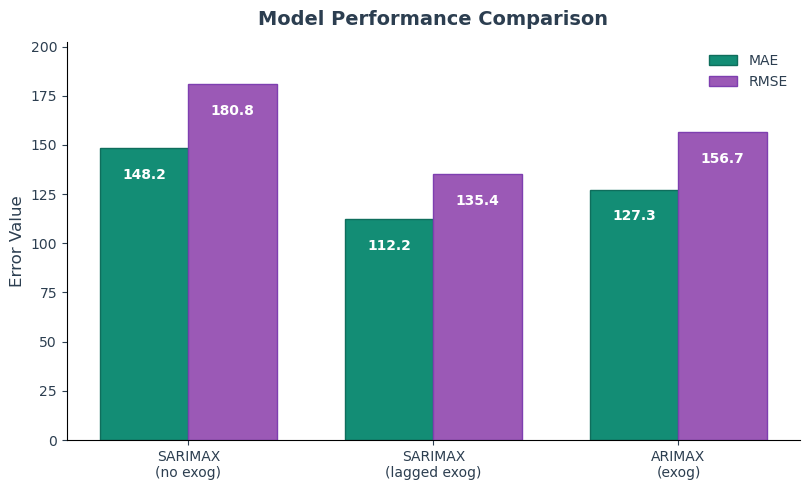

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data 
models = ["SARIMAX\n(no exog)", "SARIMAX\n(lagged exog)", "ARIMAX\n(exog)"]
mae    = [148.25, 112.23, 127.32]
rmse   = [180.77, 135.36, 156.71]

#  Colors 
TEAL      = "#138D75"
AMETHYST  = "#9B59B6"
TEXT_GRAY = "#2C3E50"

x = np.arange(len(models))
width = 0.36

# Global style
plt.rcParams["axes.grid"] = False
plt.rcParams["figure.facecolor"] = "white"

fig, ax = plt.subplots(figsize=(8.2, 5))

# Bars
b1 = ax.bar(x - width/2, mae,  width, label="MAE",  color=TEAL,     edgecolor="#0f6e5c")
b2 = ax.bar(x + width/2, rmse, width, label="RMSE", color=AMETHYST, edgecolor="#7E3FB0")

# Axes styling
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold", color=TEXT_GRAY, pad=12)
ax.set_ylabel("Error Value", fontsize=12, color=TEXT_GRAY)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.tick_params(axis="y", labelsize=10, colors=TEXT_GRAY)
ax.tick_params(axis="x", colors=TEXT_GRAY)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Y limit with headroom
ax.set_ylim(0, max(rmse) * 1.12)

# Value labels
def autolabel(bars, color_fg="white"):
    for bar in bars:
        h = bar.get_height()
        xpos = bar.get_x() + bar.get_width()/2
        # decide placement
        if h > ax.get_ylim()[1] * 0.12:
            # inside bar
            ax.text(xpos, h - (ax.get_ylim()[1]*0.05), f"{h:.1f}",
                    ha="center", va="top", fontsize=10, color=color_fg, weight="semibold")
        else:
            # above bar
            ax.text(xpos, h + (ax.get_ylim()[1]*0.015), f"{h:.1f}",
                    ha="center", va="bottom", fontsize=10, color=TEXT_GRAY)

autolabel(b1, color_fg="white")
autolabel(b2, color_fg="white")

# Legend
leg = ax.legend(frameon=False, fontsize=10, loc="upper right")
for text in leg.get_texts():
    text.set_color(TEXT_GRAY)

plt.tight_layout()
plt.show()